# Chinese Chess Recognition — Pipeline

Notebook này trình bày toàn bộ pipeline nhận diện nước đi cờ tướng từ camera/video thời gian thực.

## Sơ đồ tổng quan
```
[Camera/Video]
     ↓
[ROI Extraction] — crop & resize về 480×480
     ↓
[Motion Detection] — absdiff giữa các frame
     ↓ (sau khi ổn định ~0.3s)
[Board Detection — YOLO] — detect toàn bàn cờ
     ↓
[Move Inference] — so sánh prev_map vs curr_map
     ↓
[Rule Validation] — kiểm tra luật cờ tướng
     ↓
[Save Snapshot + Update State]
```

## 1. Cài đặt thư viện

In [1]:
# !pip install ultralytics opencv-python numpy

## 2. piece_detector.py — YOLO Wrapper

Module này bao gồm:
- `CANONICAL_LABELS`: 15 nhãn chuẩn (14 loại quân + `grid`)
- `LABEL_ALIASES`: map tên tiếng Anh → nhãn chuẩn
- `PieceDetector`: class chạy YOLO inference

In [2]:
import os
import cv2
import numpy as np
from ultralytics import YOLO


CANONICAL_LABELS = {
    "b_jiang", "b_ju", "b_ma", "b_pao", "b_shi", "b_xiang", "b_zu",
    "r_bing", "r_ju", "r_ma", "r_pao", "r_shi", "r_shuai", "r_xiang",
    "grid",
}

LABEL_ALIASES = {
    "b_general": "b_jiang", "b_king": "b_jiang", "black_general": "b_jiang", "black_king": "b_jiang",
    "b_rook": "b_ju", "b_chariot": "b_ju", "black_rook": "b_ju", "black_chariot": "b_ju",
    "b_knight": "b_ma", "black_knight": "b_ma", "b_horse": "b_ma", "black_horse": "b_ma",
    "b_cannon": "b_pao", "black_cannon": "b_pao",
    "b_guard": "b_shi", "black_guard": "b_shi", "b_advisor": "b_shi", "b_adviser": "b_shi",
    "black_advisor": "b_shi", "black_adviser": "b_shi",
    "b_elephant": "b_xiang", "black_elephant": "b_xiang", "b_bishop": "b_xiang", "black_bishop": "b_xiang",
    "b_soldier": "b_zu", "b_pawn": "b_zu", "black_soldier": "b_zu", "black_pawn": "b_zu",
    "r_general": "r_shuai", "r_king": "r_shuai", "red_general": "r_shuai", "red_king": "r_shuai",
    "r_rook": "r_ju", "r_chariot": "r_ju", "red_rook": "r_ju", "red_chariot": "r_ju",
    "r_knight": "r_ma", "red_knight": "r_ma", "r_horse": "r_ma", "red_horse": "r_ma",
    "r_cannon": "r_pao", "red_cannon": "r_pao",
    "r_guard": "r_shi", "red_guard": "r_shi", "r_advisor": "r_shi", "r_adviser": "r_shi",
    "red_advisor": "r_shi", "red_adviser": "r_shi",
    "r_elephant": "r_xiang", "red_elephant": "r_xiang", "r_bishop": "r_xiang", "red_bishop": "r_xiang",
    "r_soldier": "r_bing", "r_pawn": "r_bing", "red_soldier": "r_bing", "red_pawn": "r_bing",
    "empty": "grid", "none": "grid", "background": "grid", "board": "grid",
    "intersection": "grid", "cross": "grid",
}


class PieceDetector:
    def __init__(self, weights_path: str = "./weights.pt", imgsz: int = 640,
                 conf: float = 0.25, iou: float = 0.45):
        if not os.path.exists(weights_path):
            raise FileNotFoundError(f"Khong tim thay model: {weights_path}")
        self.model = YOLO(weights_path)
        self.imgsz = imgsz
        self.conf = conf
        self.iou = iou
        self.names = self.model.names

    def _resolve_name(self, class_id: int) -> str:
        names = self.names
        if isinstance(names, dict):
            return str(names.get(class_id, class_id))
        if isinstance(names, list) and 0 <= class_id < len(names):
            return str(names[class_id])
        return str(class_id)

    @staticmethod
    def normalize_label(raw_label: str) -> str:
        key = raw_label.strip().lower().replace("-", "_").replace(" ", "_")
        if key in CANONICAL_LABELS:
            return key
        return LABEL_ALIASES.get(key, key)

    def predict_piece(self, crop: np.ndarray, default_label: str = "grid") -> str:
        """Nhận diện loại quân từ crop ảnh một ô cờ."""
        if crop is None or crop.size == 0:
            return default_label
        h, w = crop.shape[:2]
        min_side = min(h, w)
        if min_side < 160:
            scale = max(1, int(np.ceil(160 / max(1, min_side))))
            crop = cv2.resize(crop, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
        results = self.model.predict(
            source=crop, imgsz=self.imgsz, conf=min(self.conf, 0.05),
            iou=self.iou, verbose=False, device="cpu",
        )
        if not results:
            return default_label
        boxes = results[0].boxes
        if boxes is None or len(boxes) == 0:
            return default_label
        confs = boxes.conf.detach().cpu().numpy()
        class_ids = boxes.cls.detach().cpu().numpy().astype(int)
        ranked_indices = np.argsort(-confs)
        best_grid_label = default_label
        for idx in ranked_indices:
            raw_label = self._resolve_name(int(class_ids[idx]))
            normalized = self.normalize_label(raw_label)
            if normalized not in CANONICAL_LABELS:
                continue
            if normalized != "grid":
                return normalized
            best_grid_label = normalized
        return best_grid_label

    def predict_detections(self, image: np.ndarray, conf: float | None = None) -> list[dict]:
        """Chạy YOLO detect toàn ảnh, trả về list dict mỗi detection."""
        if image is None or image.size == 0:
            return []
        results = self.model.predict(
            source=image, imgsz=self.imgsz,
            conf=self.conf if conf is None else conf,
            iou=self.iou, verbose=False, device="cpu",
        )
        if not results:
            return []
        boxes = results[0].boxes
        if boxes is None or len(boxes) == 0:
            return []
        xyxy = boxes.xyxy.detach().cpu().numpy()
        confs = boxes.conf.detach().cpu().numpy()
        class_ids = boxes.cls.detach().cpu().numpy().astype(int)
        detections = []
        for box, score, cls_id in zip(xyxy, confs, class_ids):
            raw_label = self._resolve_name(int(cls_id))
            label = self.normalize_label(raw_label)
            x1, y1, x2, y2 = box.tolist()
            detections.append({
                "label": label, "raw_label": raw_label, "conf": float(score),
                "x1": float(x1), "y1": float(y1), "x2": float(x2), "y2": float(y2),
                "cx": float((x1 + x2) * 0.5), "cy": float((y1 + y2) * 0.5),
            })
        return detections

    def predict_board_state(self, image, begin_pt, grid_w, grid_h, conf=None):
        """Inference toàn bàn → snap về ô lưới → trả (label_map, conf_map)."""
        if image is None or image.size == 0:
            return {}, {}
        detections = self.predict_detections(image, conf=conf)
        board = {}
        for det in detections:
            label = det['label']
            if label == 'grid':
                continue
            bx = int(round((det['cx'] - begin_pt[0]) / grid_w))
            by = int(round((det['cy'] - begin_pt[1]) / grid_h))
            if not (0 <= bx <= 8 and 0 <= by <= 9):
                continue
            key = (bx, by)
            if key not in board or det['conf'] > board[key][1]:
                board[key] = (label, float(det['conf']))
        label_map = {k: v[0] for k, v in board.items()}
        conf_map = {k: v[1] for k, v in board.items()}
        return label_map, conf_map

## 3. Hằng số & Cấu hình

In [3]:
import threading
import queue as _q
from collections import Counter

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# --- Cấu hình chính ---
ENFORCE_MOVE_RULES          = True    # Bật/tắt kiểm tra luật cờ
MOVE_CAPTURE_DIR            = './Move_Captures'
STABLE_DIFF_THRESHOLD       = 1300   # Số pixel thay đổi để xem là "đang di chuyển"
STABLE_SECONDS_REQUIRED     = 0.3    # Giây cần ổn định sau khi di chuyển xong
STEP0_STABLE_DIFF_THRESHOLD = 1800   # Ngưỡng ổn định khi chờ Step 0
STEP0_STABLE_SECONDS_REQUIRED = 2.0  # Giây cần ổn định để chụp Step 0
PROCESS_SIZE                = 480    # Kích thước ảnh sau resize
ROI_MOVE_STEP               = 12     # Pixel di chuyển ROI mỗi lần bấm phím
ROI_SIZE_STEP               = 20     # Pixel tăng/giảm kích thước ROI
MOTION_BINARY_THRESHOLD     = 15     # Ngưỡng threshold cho motion mask
DETECT_DURING_MOTION_EVERY  = 4      # Detect mỗi N frame khi đang chuyển động (nếu bật)
ENABLE_DETECT_DURING_MOTION = False  # Fast-move fallback
BOARD_DETECT_CONF           = 0.12   # YOLO confidence threshold khi detect bàn cờ
LABEL_SWITCH_CONF_MIN       = 0.45   # Conf tối thiểu để chấp nhận đổi nhãn quân cờ
SOLDIER_ADVISER_SWITCH_CONF_MIN = 0.72  # Conf tối thiểu cho flip bing↔shi / zu↔shi

# --- Danh sách nhãn ---
pieceTypeList = [
    'b_jiang','b_ju','b_ma','b_pao','b_shi','b_xiang','b_zu',
    'r_bing','r_ju','r_ma','r_pao','r_shi','r_shuai','r_xiang'
]
pieceTypeList_with_grid = pieceTypeList[:7] + ['grid'] + pieceTypeList[7:]
label_type = pieceTypeList_with_grid

dic = {
    'b_jiang':'Black King',    'b_ju':'Black Rook',    'b_ma':'Black Knight',
    'b_pao':'Black Cannon',    'b_shi':'Black Guard',  'b_xiang':'Black Elephant',
    'b_zu':'Black Pawn',       'r_bing':'Red Soldier', 'r_ju':'Red Chariot',
    'r_ma':'Red Horse',        'r_pao':'Red Cannon',   'r_shi':'Red Adviser',
    'r_shuai':'Red General',   'r_xiang':'Red Minister'
}

board_state_map = {}
print("Cấu hình đã load.")

Cấu hình đã load.


## 4. TemporalBoardVoter — Lọc nhiễu bằng voting

Lưu lịch sử N lần quét gần nhất, vote đa số cho từng ô để lọc nhiễu single-frame của YOLO
(ví dụ nhầm `r_bing` ↔ `r_shi`, `b_zu` ↔ `b_shi`).

In [4]:
class TemporalBoardVoter:
    def __init__(self, window: int = 5):
        self.window = window
        self._history: list[dict] = []

    def push(self, label_map: dict) -> None:
        self._history.append(dict(label_map))
        if len(self._history) > self.window:
            self._history.pop(0)

    def clear(self) -> None:
        self._history.clear()

    def ready(self) -> bool:
        return len(self._history) >= 2

    def get_stable_state(self) -> dict:
        """Majority-vote nhãn theo từng ô (bx, by). Ô 'grid' bị loại."""
        if not self._history:
            return {}
        all_keys = set()
        for m in self._history:
            all_keys.update(m.keys())
        threshold = max(1, len(self._history) // 2 + 1)
        result = {}
        for key in all_keys:
            labels = [m.get(key, 'grid') for m in self._history]
            best_label, best_count = Counter(labels).most_common(1)[0]
            if best_label != 'grid' and best_count >= threshold:
                result[key] = best_label
        return result


board_voter = TemporalBoardVoter(window=5)
print("TemporalBoardVoter khởi tạo.")

TemporalBoardVoter khởi tạo.


## 5. Background Detection Thread

Chạy inference trong background thread để không block main display loop.

In [5]:
_detect_lock = threading.Lock()
_detect_active = False
_detect_result_q = _q.Queue(maxsize=1)

def _detection_worker(frame: np.ndarray) -> None:
    global _detect_active
    result = PiecesChangeDetection(frame)  # Hàm định nghĩa ở section 9
    try:
        _detect_result_q.put_nowait(result)
    except _q.Full:
        pass
    with _detect_lock:
        _detect_active = False

print("Background detection thread setup.")

Background detection thread setup.


## 6. Hàm tiện ích ROI & Grid

In [6]:
def normalize_roi(x, y, side, frame_w, frame_h):
    """Clamp ROI để không vượt biên frame."""
    side = int(max(200, min(side, min(frame_w, frame_h))))
    x = int(max(0, min(x, frame_w - side)))
    y = int(max(0, min(y, frame_h - side)))
    return x, y, side


def extract_process_frame(frame, roi):
    """Crop ROI từ frame gốc và resize về PROCESS_SIZE×PROCESS_SIZE."""
    x, y, side = roi
    patch = frame[y:y + side, x:x + side]
    if patch.size == 0:
        return None
    return cv2.resize(patch, (PROCESS_SIZE, PROCESS_SIZE), interpolation=cv2.INTER_AREA)


def point_to_board_xy(point):
    """Chuyển tọa độ pixel → ô lưới (col, row) trên bàn cờ."""
    bx = int(np.around((point[0] - begin_point[0]) / GRID_WIDTH_HORI))
    by = int(np.around((point[1] - begin_point[1]) / GRID_WIDTH_VERTI))
    return bx, by


def board_xy_to_pixel(cell):
    """Chuyển ô lưới → tọa độ pixel (tâm ô)."""
    return (
        int(np.around(begin_point[0] + cell[0] * GRID_WIDTH_HORI)),
        int(np.around(begin_point[1] + cell[1] * GRID_WIDTH_VERTI)),
    )


def crop_with_margin(img, circle, margin_scale=1.6):
    """Crop vùng quanh tâm circle với margin."""
    cx, cy, r = int(circle[0]), int(circle[1]), int(circle[2])
    m = max(2, int(r * margin_scale))
    h_img, w_img = img.shape[:2]
    x1, x2 = max(0, cx - m), min(w_img, cx + m)
    y1, y2 = max(0, cy - m), min(h_img, cy + m)
    return img[y1:y2, x1:x2]


print("Utility functions defined.")

Utility functions defined.


## 7. Khởi tạo — `Initialization()`

Bước này:
1. Tải model YOLO
2. Dùng **HoughCircles** trên Step 0 để tính `begin_point`, `GRID_WIDTH_HORI`, `GRID_WIDTH_VERTI`
3. Detect trạng thái ban đầu của bàn cờ → `board_state_map`

In [7]:
def Initialization():
    global GRID_WIDTH_HORI, GRID_WIDTH_VERTI, begin_point, step, legal_move, model, target_size, isRed

    step        = 0       # Số bước đã đi
    legal_move  = True    # Nước đi hiện tại có hợp lệ không
    isRed       = True    # True = đến lượt Đỏ
    target_size = (640, 640)
    model = PieceDetector(weights_path='./weights.pt', imgsz=640, conf=0.05)
    os.makedirs(MOVE_CAPTURE_DIR, exist_ok=True)
    # Xóa ảnh cũ trong Move_Captures
    for name in os.listdir(MOVE_CAPTURE_DIR):
        path = os.path.join(MOVE_CAPTURE_DIR, name)
        if os.path.isfile(path):
            os.remove(path)

    # Tính khoảng cách lưới từ Step 0 bằng HoughCircles
    frame0 = cv2.imread('./Test_Image/Step 0.png', 0)
    img_circle = cv2.HoughCircles(
        frame0, cv2.HOUGH_GRADIENT, 1, 40,
        param1=100, param2=20, minRadius=18, maxRadius=22
    )[0]
    sums = np.sum(img_circle, axis=1).tolist()
    begin_point = img_circle[sums.index(min(sums))]  # Góc trên-trái
    end_point   = img_circle[sums.index(max(sums))]  # Góc dưới-phải
    GRID_WIDTH_HORI  = (end_point[0] - begin_point[0]) / 8
    GRID_WIDTH_VERTI = (end_point[1] - begin_point[1]) / 9

    init_board_state('./Test_Image/Step 0.png')
    print(f'Recognition Initialized. Grid: {GRID_WIDTH_HORI:.1f}×{GRID_WIDTH_VERTI:.1f} px/cell')


def init_board_state(step0_path):
    """Detect bàn cờ ban đầu từ ảnh Step 0."""
    global board_state_map
    board_state_map = {}
    step0_img = cv2.imread(step0_path)
    if step0_img is None:
        return
    board_state_map = detect_board_map(step0_img)  # Hàm ở section 8


print("Initialization function defined.")

Initialization function defined.


## 8. Board Detection — `detect_board_map()`

- Chạy YOLO inference toàn ảnh
- Snap tâm mỗi detection về ô lưới gần nhất
- Sửa nhãn theo vị trí (Sĩ ngoài cung → đổi thành Tốt)
- Stabilize: nếu nhãn đổi với confidence thấp → giữ nhãn cũ

In [8]:
def is_in_palace(color, bx, by):
    """Kiểm tra ô (bx, by) có nằm trong cung không."""
    if not (3 <= bx <= 5):
        return False
    if color == 'r':
        return 7 <= by <= 9
    if color == 'b':
        return 0 <= by <= 2
    return False


def correct_label_by_position(label, bx, by, score):
    """Sĩ ngoài cung → đổi thành Tốt (giảm nhầm lẫn r_bing↔r_shi)."""
    if label == 'r_shi' and not is_in_palace('r', bx, by):
        return 'r_bing'
    if label == 'b_shi' and not is_in_palace('b', bx, by):
        return 'b_zu'
    return label


def detect_board_map(frame, prev_map=None, return_conf=False):
    """
    YOLO detect → snap về lưới → stabilize nhãn.
    Trả về label_map (và conf_map nếu return_conf=True).
    """
    detections = model.predict_detections(frame, conf=BOARD_DETECT_CONF)
    board_map = {}

    for det in detections:
        label = det['label']
        if label == 'grid' or label not in dic:
            continue
        bx, by = point_to_board_xy((det['cx'], det['cy']))
        if not (0 <= bx <= 8 and 0 <= by <= 9):
            continue
        key = (bx, by)
        score = det['conf']
        label = correct_label_by_position(label, bx, by, score)
        if key not in board_map or score > board_map[key][1]:
            board_map[key] = (label, score)

    if prev_map:
        stabilized = {}
        stabilized_conf = {}
        for key, (label, score) in board_map.items():
            prev_label = prev_map.get(key)
            is_soldier_adviser_flip = (prev_label, label) in {
                ('r_bing','r_shi'), ('r_shi','r_bing'), ('b_zu','b_shi'), ('b_shi','b_zu'),
            }
            if prev_label and prev_label in dic and prev_label != label and score < LABEL_SWITCH_CONF_MIN:
                stabilized[key] = prev_label
            elif prev_label and prev_label in dic and is_soldier_adviser_flip and score < SOLDIER_ADVISER_SWITCH_CONF_MIN:
                stabilized[key] = prev_label
            else:
                stabilized[key] = label
            stabilized_conf[key] = score
        if return_conf:
            return stabilized, stabilized_conf
        return stabilized

    label_map = {k: v[0] for k, v in board_map.items()}
    if return_conf:
        conf_map = {k: v[1] for k, v in board_map.items()}
        return label_map, conf_map
    return label_map


print("detect_board_map defined.")

detect_board_map defined.


## 9. Move Detection — `PiecesChangeDetection()`

Luồng xử lý:
1. `changeDetection()` — tìm bounding rect của vùng thay đổi
2. `detect_board_map()` — lấy trạng thái bàn cờ mới
3. `infer_move_from_states()` — so sánh prev vs curr map để suy ra nước đi
4. `is_legal_move()` — kiểm tra luật
5. Cập nhật `board_state_map` và lưu ảnh

In [9]:
def changeDetection(previous_step, current_step, visual=False):
    """Tính bounding rect của vùng thay đổi giữa 2 frame."""
    current_gray  = cv2.cvtColor(current_step,  cv2.COLOR_BGR2GRAY)
    previous_gray = cv2.cvtColor(previous_step, cv2.COLOR_BGR2GRAY)
    frame_diff = cv2.absdiff(current_gray, previous_gray)
    frame_diff = cv2.medianBlur(frame_diff, 5)
    _, frame_diff = cv2.threshold(frame_diff, 0, 255, cv2.THRESH_OTSU)
    frame_diff = cv2.medianBlur(frame_diff, 5)
    x, y, w, h = cv2.boundingRect(frame_diff)
    return x, y, w, h


def _score_move_candidate(piece_label: str, begin: tuple, end: tuple) -> float:
    """
    Chấm điểm cặp (begin→end) theo luật di chuyển.
    Điểm cao = khả năng là nước đi hợp lệ cao.
    """
    if '_' not in piece_label:
        return 0.0
    variety = piece_label.split('_')[-1]
    dx = abs(end[0] - begin[0])
    dy = abs(end[1] - begin[1])
    if dx == 0 and dy == 0:
        return float('-inf')
    if variety == 'ma':    return 10.0 if (dx==1 and dy==2) or (dx==2 and dy==1) else -5.0
    if variety == 'xiang': return 10.0 if dx==2 and dy==2 else -5.0
    if variety == 'shi':   return 10.0 if dx==1 and dy==1 else -5.0
    if variety in ('jiang','shuai'): return 10.0 if dx+dy==1 else -5.0
    if variety in ('ju','pao'):      return 10.0 if (dx==0 or dy==0) else -5.0
    if variety in ('bing','zu'):     return 5.0  if dx+dy<=2 else -3.0
    return 3.0


def infer_move_from_states(prev_map: dict, curr_map: dict):
    """
    So sánh 2 trạng thái bàn cờ để suy ra (begin, end, piece_label).
    Dùng scoring thay vì lấy bừa phần tử đầu tiên.
    """
    vacated  = [k for k in prev_map if k not in curr_map]
    occupied = [k for k in curr_map if k not in prev_map]
    changed  = [k for k in prev_map if k in curr_map and prev_map[k] != curr_map[k]]

    if not vacated or len(vacated) > 2:
        return None, None, None

    dst_candidates = occupied + changed
    if not dst_candidates:
        return None, None, None

    best_begin = best_end = best_label = None
    best_score = float('-inf')

    for begin in vacated:
        piece_label = prev_map[begin]
        for end in dst_candidates:
            move_score   = _score_move_candidate(piece_label, begin, end)
            dist_penalty = (abs(end[0]-begin[0]) + abs(end[1]-begin[1])) * 0.15
            total = move_score - dist_penalty
            if total > best_score:
                best_score = total
                best_begin, best_end, best_label = begin, end, piece_label

    if best_score < 0:
        return None, None, None
    return best_begin, best_end, best_label


print("Move inference functions defined.")

Move inference functions defined.


## 10. Kiểm tra luật cờ tướng — `is_legal_move()`

| Quân | Luật |
|------|------|
| Mã (ma) | Đi hình chữ L: (1,2) hoặc (2,1) |
| Tượng (xiang) | Đi chéo 2 ô |
| Sĩ (shi) | Đi chéo 1 ô trong cung |
| Tướng (jiang/shuai) | Đi 1 ô theo hàng/cột, trong cung |
| Xe/Pháo (ju/pao) | Đi thẳng (cùng hàng hoặc cột) |
| Tốt Đỏ (bing) | Đi về phía Đen, chỉ đi ngang khi đã qua sông |
| Tốt Đen (zu) | Đi về phía Đỏ, chỉ đi ngang khi đã qua sông |

In [10]:
def is_legal_move(begin, end, predict_category):
    if predict_category == 'grid':
        return True
    updown    = abs(begin[1] - end[1])
    leftright = abs(begin[0] - end[0])
    variety   = predict_category.split('_')[-1]
    color     = predict_category.split('_')[0]
    legal = True

    if variety == 'ma':
        legal = (updown==1 and leftright==2) or (updown==2 and leftright==1)
    elif variety == 'xiang':
        legal = (updown==2 and leftright==2)
    elif variety == 'shi':
        legal = (updown==1 and leftright==1)
    elif variety in ('jiang','shuai'):
        legal = (updown==1 and leftright==0) or (updown==0 and leftright==1)
    elif variety in ('ju','pao'):
        legal = updown==0 or leftright==0
    elif variety == 'bing':
        legal = not (begin[1] < end[1]
                     or (begin[1] >= 5.0 and begin[0] != end[0])
                     or (begin[1]-end[1] > 1))
    elif variety == 'zu':
        legal = not (begin[1] > end[1]
                     or (begin[1] <= 4.0 and begin[0] != end[0])
                     or (end[1]-begin[1] > 1))

    if isRed and color == 'b':
        legal = False
        print('Lượt của Đỏ!')
    if (not isRed) and color == 'r':
        legal = False
        print('Lượt của Đen!')

    return legal


print("is_legal_move defined.")

is_legal_move defined.


## 11. Lưu ảnh nước đi — `save_move_snapshot()`

In [11]:
def save_move_snapshot(frame, step_idx, piece_name, begin, end, legal=True):
    canvas = frame.copy()
    start_pt = (
        int(np.around(begin_point[0] + begin[0] * GRID_WIDTH_HORI)),
        int(np.around(begin_point[1] + begin[1] * GRID_WIDTH_VERTI)),
    )
    end_pt = (
        int(np.around(begin_point[0] + end[0] * GRID_WIDTH_HORI)),
        int(np.around(begin_point[1] + end[1] * GRID_WIDTH_VERTI)),
    )
    arrow_color = (0, 255, 0) if legal else (0, 0, 255)
    cv2.circle(canvas, start_pt, 6, (255, 255, 255), -1)
    cv2.arrowedLine(canvas, start_pt, end_pt, arrow_color, 3, tipLength=0.25)
    status = 'LEGAL' if legal else 'ILLEGAL'
    text = f"Step {step_idx+1}: {piece_name} {begin}->{end} [{status}]"
    cv2.putText(canvas, text, (8, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                arrow_color, 2, cv2.LINE_AA)
    filename = f"step_{step_idx+1:03d}_{piece_name.replace(' ','_')}_{status}.png"
    cv2.imwrite(os.path.join(MOVE_CAPTURE_DIR, filename), canvas)


print("save_move_snapshot defined.")

save_move_snapshot defined.


## 12. `PiecesChangeDetection()` — Ghép tất cả lại

In [12]:
def PiecesChangeDetection(current_step):
    global legal_move
    previous_step = cv2.imread('./Test_Image/Step %d.png' % step)
    x, y, w, h = changeDetection(previous_step, current_step, False)
    if w * h < 30 * 30:
        return 0  # Vùng thay đổi quá nhỏ → bỏ qua

    prev_map = dict(board_state_map)
    curr_map, curr_conf_map = detect_board_map(current_step, prev_map=prev_map, return_conf=True)

    begin, end, predict_category = infer_move_from_states(prev_map, curr_map)
    if begin is None or end is None:
        return 0

    rule_piece_label = prev_map.get(begin, 'grid')
    if rule_piece_label == 'grid':
        rule_piece_label = predict_category

    piece_name = dic.get(rule_piece_label, 'Unknown piece')
    move_conf  = float(curr_conf_map.get(end, 0.0))

    legal_move = is_legal_move(begin, end, rule_piece_label) if ENFORCE_MOVE_RULES else True

    board_state_map.clear()
    board_state_map.update(curr_map)
    board_voter.clear()

    print(f'{piece_name} moved {begin} → {end}  (conf={move_conf:.3f}, legal={legal_move})')

    if legal_move:
        cv2.imwrite('./Test_Image/Step %d.png' % (step + 1), current_step)
        save_move_snapshot(current_step, step, piece_name, begin, end, legal=True)
        return 1  # Hợp lệ → main loop tăng step, đổi lượt

    cv2.imwrite('./Test_Image/Step %d.png' % step, current_step)
    save_move_snapshot(current_step, step, piece_name, begin, end, legal=False)
    legal_move = True
    return 0


print("PiecesChangeDetection defined.")

PiecesChangeDetection defined.


## 13. Vòng lặp chính — Main Loop

### Giai đoạn 1: Chờ Step 0 (Auto-capture)
- Hiển thị ROI có thể điều chỉnh bằng I/J/K/L/+/-/F
- Tự động chụp khi frame ổn định 2 giây

### Giai đoạn 2: Tracking nước đi
- Phát hiện chuyển động → chờ ổn định → trigger detection async

In [13]:
# Chạy cell này để bắt đầu (cần có file video hoặc camera)
VIDEO_SOURCE = './Sources/test12.mp4'  # Đổi thành 0 để dùng webcam

cap = cv2.VideoCapture(VIDEO_SOURCE)
if not cap.isOpened():
    print('Không mở được nguồn video.')
else:
    source_fps = cap.get(cv2.CAP_PROP_FPS)
    if not source_fps or source_fps <= 1 or source_fps > 240:
        source_fps = 30.0

    STEP0_STABLE_FRAMES_REQUIRED = max(8,  int(source_fps * STEP0_STABLE_SECONDS_REQUIRED))
    STABLE_FRAMES_REQUIRED       = max(4,  int(source_fps * STABLE_SECONDS_REQUIRED))
    MOVE_DEBOUNCE_FRAMES         = max(3,  int(source_fps * 0.25))
    frame_wait_ms                = max(1,  int(1000.0 / source_fps))

    print(f"FPS={source_fps:.0f}, Step0 cần {STEP0_STABLE_FRAMES_REQUIRED} frames ổn định,"
          f" Move cần {STABLE_FRAMES_REQUIRED} frames ổn định")

    # ── Giai đoạn 1: Chờ Step 0 ──────────────────────────────────────────
    step0 = None
    os.makedirs('./Test_Image', exist_ok=True)
    init_prev_gray   = None
    init_stable_count = 0
    roi = None

    while True:
        ret, raw_frame = cap.read()
        if not ret:
            print("Hết video.")
            break

        h, w = raw_frame.shape[:2]
        if roi is None:
            side = int(min(w, h) * 0.95)
            roi  = normalize_roi((w-side)//2, (h-side)//2, side, w, h)

        view = raw_frame.copy()
        x0, y0, side = roi
        cv2.rectangle(view, (x0, y0), (x0+side, y0+side), (255,255,255), 2)

        current_frame = extract_process_frame(raw_frame, roi)
        if current_frame is None:
            break

        gray = cv2.cvtColor(current_frame, cv2.COLOR_BGR2GRAY)
        if init_prev_gray is not None:
            delta = cv2.absdiff(gray, init_prev_gray)
            score = cv2.countNonZero(cv2.threshold(delta, 20, 255, cv2.THRESH_BINARY)[1])
            init_stable_count = init_stable_count + 1 if score < STEP0_STABLE_DIFF_THRESHOLD else 0
        init_prev_gray = gray

        remaining = max(0, STEP0_STABLE_FRAMES_REQUIRED - init_stable_count)
        cv2.putText(view, f"Auto Step0 in: {remaining}", (8, 24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2, cv2.LINE_AA)
        cv2.putText(view, "I/J/K/L: move ROI, +/-: size, F: fit max", (8, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,0), 2, cv2.LINE_AA)
        cv2.imshow("Canh khung - tu dong chup Step 0", view)

        key = cv2.waitKey(frame_wait_ms) & 0xFF
        if init_stable_count >= STEP0_STABLE_FRAMES_REQUIRED:
            step0 = current_frame.copy()
            cv2.imwrite('./Test_Image/Step 0.png', step0)
            print("Đã tự động chụp Step 0, shape =", step0.shape)
            break

        # Điều chỉnh ROI bằng bàn phím
        if   key in (ord('i'),ord('I')): roi = normalize_roi(x0, y0-ROI_MOVE_STEP, side, w, h); init_stable_count=0
        elif key in (ord('k'),ord('K')): roi = normalize_roi(x0, y0+ROI_MOVE_STEP, side, w, h); init_stable_count=0
        elif key in (ord('j'),ord('J')): roi = normalize_roi(x0-ROI_MOVE_STEP, y0, side, w, h); init_stable_count=0
        elif key in (ord('l'),ord('L')): roi = normalize_roi(x0+ROI_MOVE_STEP, y0, side, w, h); init_stable_count=0
        elif key in (ord('+'),ord('=')): roi = normalize_roi(x0-ROI_SIZE_STEP//2, y0-ROI_SIZE_STEP//2, side+ROI_SIZE_STEP, w, h); init_stable_count=0
        elif key in (ord('-'),ord('_')): roi = normalize_roi(x0+ROI_SIZE_STEP//2, y0+ROI_SIZE_STEP//2, side-ROI_SIZE_STEP, w, h); init_stable_count=0
        elif key in (ord('f'),ord('F')):
            fit_side = int(min(w,h)*0.98)
            roi = normalize_roi((w-fit_side)//2, (h-fit_side)//2, fit_side, w, h)
            init_stable_count = 0
        if key == ord('q'):
            break

    # ── Giai đoạn 2: Main loop tracking ──────────────────────────────────
    if step0 is not None:
        previous_frame = step0.copy()
        prev_gray      = cv2.cvtColor(previous_frame, cv2.COLOR_BGR2GRAY)
        stable_count   = 0
        motion_active  = False
        frame_index    = 0
        detect_cooldown = 0

        Initialization()

        while cap.isOpened():
            ret, raw_frame = cap.read()
            if not ret:
                break
            frame_index += 1

            h, w = raw_frame.shape[:2]
            roi = normalize_roi(roi[0], roi[1], roi[2], w, h)
            current_frame = extract_process_frame(raw_frame, roi)
            if current_frame is None:
                break

            gray = cv2.cvtColor(current_frame, cv2.COLOR_BGR2GRAY)
            frame_delta  = cv2.absdiff(gray, prev_gray)
            motion_score = cv2.countNonZero(
                cv2.threshold(frame_delta, MOTION_BINARY_THRESHOLD, 255, cv2.THRESH_BINARY)[1]
            )

            if detect_cooldown > 0:
                detect_cooldown -= 1

            # Nhận kết quả từ background thread (non-blocking)
            try:
                num = _detect_result_q.get_nowait()
                if num == 1:
                    step  += 1
                    isRed  = bool(1 - isRed)
                    detect_cooldown = MOVE_DEBOUNCE_FRAMES
            except _q.Empty:
                pass

            # Motion / stability tracking
            if motion_score < STABLE_DIFF_THRESHOLD:
                stable_count += 1
            else:
                motion_active = True
                stable_count  = 0
                board_voter.clear()

            # Trigger async detection khi đủ điều kiện
            with _detect_lock:
                can_detect = not _detect_active

            if detect_cooldown == 0 and motion_active and stable_count >= STABLE_FRAMES_REQUIRED and can_detect:
                with _detect_lock:
                    _detect_active = True
                frame_copy = current_frame.copy()
                threading.Thread(target=_detection_worker, args=(frame_copy,), daemon=True).start()
                motion_active = False
                stable_count  = 0

            previous_frame = current_frame.copy()
            prev_gray = gray

            # Hiển thị
            display     = current_frame.copy()
            status_text = 'MOVING' if motion_active else f'STABLE {stable_count}/{STABLE_FRAMES_REQUIRED}'
            turn_text   = 'Red' if isRed else 'Black'
            color       = (0,0,255) if motion_active else (0,255,0)
            cv2.putText(display, f'Step {step} | {turn_text} | {status_text}',
                        (8, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2, cv2.LINE_AA)
            cv2.imshow('Chinese Chess Tracker', display)
            key = cv2.waitKey(frame_wait_ms) & 0xFF
            if key == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()
    print("Done.")

FPS=30, Step0 cần 60 frames ổn định, Move cần 9 frames ổn định
Đã tự động chụp Step 0, shape = (480, 480, 3)
Recognition Initialized. Grid: 49.5×49.7 px/cell
Red Soldier moved (4, 6) → (4, 5)  (conf=0.663, legal=True)
Black Rook moved (8, 0) → (8, 2)  (conf=0.837, legal=True)
Red General moved (4, 9) → (4, 8)  (conf=0.886, legal=True)
Black Pawn moved (2, 3) → (2, 4)  (conf=0.865, legal=True)
Red Minister moved (2, 9) → (4, 7)  (conf=0.818, legal=True)
Black Pawn moved (8, 3) → (8, 4)  (conf=0.850, legal=True)
Red Minister moved (8, 6) → (6, 4)  (conf=0.839, legal=True)
Black Knight moved (1, 0) → (2, 2)  (conf=0.692, legal=True)
Lượt của Đỏ!
Black Pawn moved (4, 3) → (4, 4)  (conf=0.858, legal=False)
Red Chariot moved (0, 9) → (0, 6)  (conf=0.837, legal=True)
Black Guard moved (5, 0) → (4, 1)  (conf=0.870, legal=True)
Red Minister moved (4, 7) → (6, 5)  (conf=0.844, legal=True)
Done.


## 14. Demo: Test nhận diện trên ảnh tĩnh

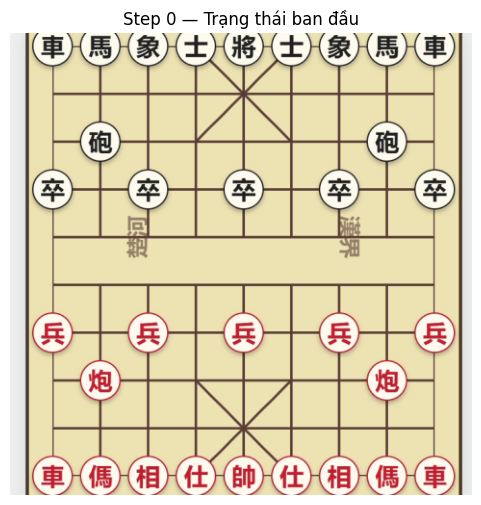

In [14]:
import matplotlib.pyplot as plt

# Đọc ảnh Step 0 và hiển thị
step0_img = cv2.imread('./Test_Image/Step 0.png')
if step0_img is not None:
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(step0_img, cv2.COLOR_BGR2RGB))
    plt.title('Step 0 — Trạng thái ban đầu')
    plt.axis('off')
    plt.show()
else:
    print("Không tìm thấy Step 0.png")

In [15]:
# Xem kết quả nhận diện bàn cờ ban đầu
# (Cần chạy Initialization() trước)
# Initialization()
# for (col, row), label in sorted(board_state_map.items()):
#     print(f"  ({col},{row}): {label:10s} — {dic.get(label, '')}")

---

## Tổng quan Pipeline (lý thuyết)

### 1. Khởi động & Step 0 — Canh bàn cờ tự động

- Mở camera/video (`real_time_test.py:881`)
- Hiển thị khung hình để user dùng `I/J/K/L/+/-/F` canh bàn cờ vào ROI
- Tự động chụp **Step 0** khi frame ổn định đủ **2 giây** (không còn chuyển động)
- Dùng **HoughCircles** trên Step 0 để xác định `begin_point`, `GRID_WIDTH_HORI`, `GRID_WIDTH_VERTI` → tọa độ từng ô cờ

---

### 2. Khởi tạo trạng thái bàn cờ ban đầu

- `init_board_state()` gọi YOLO detect trên Step 0
- Tạo `board_state_map = dict {(col, row): piece_label}` — bản đồ quân cờ hiện tại

---

### 3. Vòng lặp chính — Motion Detection

- Mỗi frame: crop ROI → resize về `480×480`
- So sánh với frame trước bằng `cv2.absdiff` → tính `motion_score`
- Nếu `motion_score > STABLE_DIFF_THRESHOLD`: bàn có người đang di chuyển → `motion_active = True`, reset `stable_count`
- Nếu ngược lại: `stable_count += 1`

---

### 4. Trigger Detection bất đồng bộ

- Khi `motion_active == True` và `stable_count >= STABLE_FRAMES_REQUIRED` (≈0.3s ổn định sau khi di chuyển): spawn **background thread** chạy `PiecesChangeDetection()`
- Thread gửi kết quả vào queue → main loop nhận non-blocking, không bị đơ

---

### 5. Nhận diện nước đi — `PiecesChangeDetection()`

```
frame hiện tại
    ↓
changeDetection() → tìm vùng thay đổi (bounding rect của diff)
    ↓
detect_board_map() → YOLO inference toàn bàn → prev_map vs curr_map
    ↓
infer_move_from_states() → so sánh 2 map, tìm (begin, end)
    ↓
is_legal_move() → kiểm tra luật cờ tướng
    ↓
Cập nhật board_state_map
```

---

### 6. `detect_board_map()` — Nhận diện bàn cờ bằng YOLO

- YOLO (`weights.pt`) chạy inference toàn ảnh với `conf=0.12`
- Mỗi detection: snap tâm về ô lưới `(bx, by)` gần nhất qua `point_to_board_xy()`
- `correct_label_by_position()`: nếu `r_shi`/`b_shi` (Sĩ) nằm ngoài cung → đổi thành `r_bing`/`b_zu`
- **Stabilization**: nếu nhãn đổi so với frame trước nhưng confidence thấp → giữ nhãn cũ

---

### 7. `infer_move_from_states()` — Suy luận nước đi

- Tìm ô **bị mất quân** (`vacated`) và ô **mới có quân** (`occupied/changed`)
- Dùng `_score_move_candidate()` để chấm điểm từng cặp `(begin → end)` dựa vào luật di chuyển của từng loại quân
- Chọn cặp điểm cao nhất → đó là nước đi

---

### 8. Kiểm tra luật cờ tướng

`is_legal_move()` kiểm tra theo từng loại quân:

| Quân | Ký hiệu | Luật di chuyển |
|------|---------|----------------|
| Mã (Knight) | `ma` | Đi hình chữ L: (1,2) hoặc (2,1) |
| Tượng (Elephant) | `xiang` | Đi chéo 2 ô |
| Sĩ (Advisor) | `shi` | Đi chéo 1 ô trong cung |
| Xe (Rook) | `ju` | Đi thẳng (cùng hàng hoặc cột) |
| Pháo (Cannon) | `pao` | Đi thẳng (cùng hàng hoặc cột) |
| Tốt Đỏ (Soldier) | `bing` | Đi về phía Đen; qua sông mới được đi ngang |
| Tốt Đen (Pawn) | `zu` | Đi về phía Đỏ; qua sông mới được đi ngang |
| Lượt đi | | Kiểm tra đúng màu quân (`isRed`) |

---

### 9. Lưu kết quả

- **Hợp lệ**: lưu `Step N+1.png`, tăng `step`, đổi lượt `isRed`
- Vẽ mũi tên lên ảnh + lưu vào `Move_Captures/step_NNN_PieceName_LEGAL.png`
- **Bất hợp lệ**: in cảnh báo, không tăng bước, cập nhật lại Step 0 để tránh phát hiện lại cùng nước đi

---

## Sơ đồ file chính

| File | Vai trò |
|------|---------|
| `real_time_test.py` | Pipeline chính: motion detection, vòng lặp, điều phối |
| `piece_detector.py` | Wrapper YOLO: detect toàn bàn, classify từng ô |
| `AdjustCameraLocation.py` | Địa chỉ IP camera |
| `weights.pt` | Model YOLO đã train nhận diện 14 loại quân cờ |
| `Test_Image/Step N.png` | Ảnh bàn cờ sau mỗi nước đi hợp lệ |
| `Move_Captures/` | Ảnh snapshot với mũi tên LEGAL/ILLEGAL |
